# 02 · Brechas de desempeño — Pruebas APRENDER 2016–2025

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/02_brechas.ipynb)

Análisis **descriptivo** de cómo evolucionan las **brechas de desempeño** dentro de las cohortes comparables de APRENDER:
por **sector** (estatal / privado), **ámbito** (urbano / rural) y **provincia**. Sin econometría.

Consume el dataset de [`00_consolidacion.ipynb`](00_consolidacion.ipynb): en **Colab** lee desde
*Mi unidad/`pruebas_aprender/parquet`*; en **local**, desde `datos_consolidados/`. No hace falta correr el 01.

## Qué se compara
- **Cohortes (misma nivel/grado/cobertura, escala de 4 niveles):**
  - **Primaria 6° grado – Censal:** 2016 · 2018 · 2021 · 2023 · 2025.
  - **Secundaria 5-6° año – Censal:** 2016 · 2017 · 2019 · 2022 · 2024.
- **Áreas:** Lengua y Matemática.
- **Indicador principal:** % de estudiantes en **Satisfactorio + Avanzado**; complementario: % **Por debajo del básico**.
  `valor` es un conteo **ponderado** → los % se calculan sumando conteos dentro de cada grupo.
- **Brecha** = diferencia en **puntos porcentuales (pp)** entre grupos (privado − estatal; urbano − rural).

## Límites (verificados contra los datos)
- **Nivel socioeconómico (NSE): no se puede cruzar con el desempeño en estas bases.** Los archivos agregados traen el
  desempeño y el NSE como conteos **separados** por celda geográfica (jurisdicción × departamento × sector × ámbito),
  no su distribución conjunta. La brecha por NSE requiere los **microdatos** (hay `.sav` de 2024).
- **Chubut no tiene datos en Secundaria 2019.**
- **Matemática Secundaria 2022:** la fuente no publica el nivel *Avanzado* (no afecta Satisf+Avanz de forma relevante:
  en 2024 Avanzado es ~0,1%).
- Los nombres de provincia cambian entre años (p. ej. "Buenos aires", "Ciudad de Buenos Aires"): se normalizan.
- Los grupos chicos (ámbito rural en provincias pequeñas) son más volátiles: leer con cuidado.

---
## 0 · Setup y carga

In [1]:
import os, re, unicodedata, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as pads

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')
assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb.')
plt.rcParams['figure.dpi'] = 110

# Carpeta de salida: gráficos a 300 dpi + Excel con las tablas (se descargan en un zip al final)
GRAF = os.path.abspath('graficos_brechas'); os.makedirs(GRAF, exist_ok=True)
_figs = []
def guardar(fig, nombre):
    fig.savefig(os.path.join(GRAF, nombre + '.png'), dpi=300, bbox_inches='tight')
    _figs.append(nombre); return fig
def nota(fig, texto):
    fig.text(0.01, -0.01, texto, fontsize=8, color='gray', ha='left', va='top')
print('Datos consolidados en:', OUT)
print('Salidas (gráficos 300 dpi + Excel) en:', GRAF)

Datos consolidados en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados
Salidas (gráficos 300 dpi + Excel) en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_brechas


---
## 1 · Funciones y carga de las cohortes

In [2]:
# --- Cohortes comparables (misma nivel/grado/cobertura) ---
COHORTES = {
    'Primaria 6°':     dict(nivel='Primaria',   grado='6 grado', anios=[2016, 2018, 2021, 2023, 2025]),
    'Secundaria 5-6°': dict(nivel='Secundaria', grado='5-6 año', anios=[2016, 2017, 2019, 2022, 2024]),
}
AREAS = ['Lengua', 'Matematica']
ORDEN4 = ['Por debajo del básico', 'Básico', 'Satisfactorio', 'Avanzado']

def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()
def harmonizar_nivel(op):
    t = _n(op)
    if 'por debajo' in t: return 'Por debajo del básico'
    if t == 'basico': return 'Básico'
    if 'satisfactorio' in t: return 'Satisfactorio'
    if 'avanzado' in t: return 'Avanzado'
    return None

# Nombres de provincia homogéneos entre años
PROV_ALIAS = {'buenos aires': 'Buenos Aires', 'ciudad autonoma de buenos aires': 'CABA', 'ciudad de buenos aires': 'CABA',
              'tierra del fuego': 'Tierra del Fuego', 'tierra del fuego antartida e islas del atlantico sur': 'Tierra del Fuego'}
def norm_prov(s):
    return PROV_ALIAS.get(_n(s), str(s).strip())

def cargar_cohorte(nombre):
    c = COHORTES[nombre]; partes = []
    for anio in c['anios']:
        filtro = ((pads.field('tipo_variable') == 'desempeño') & (pads.field('cobertura') == 'Censal')
                  & (pads.field('nivel') == c['nivel']) & (pads.field('grado') == c['grado']))
        d = (pads.dataset(os.path.join(OUT, 'aprender_long', f'anio={anio}'), format='parquet')
             .to_table(filter=filtro, columns=['area', 'jurisdiccion', 'sector', 'ambito', 'variable', 'valor']).to_pandas())
        partes.append(d[d.area.isin(AREAS)].assign(anio=anio))
    d = pd.concat(partes, ignore_index=True)
    d['nivel_desemp'] = d['variable'].str.split('_', n=1).str[1].map(harmonizar_nivel)
    d['provincia'] = d['jurisdiccion'].map(norm_prov)
    return d.assign(cohorte=nombre).dropna(subset=['nivel_desemp'])

def indicadores(df, por):
    """% por nivel de desempeño, Satisf+Avanz y cantidad (ponderada) de estudiantes, por los grupos `por`."""
    t = (df.groupby(por + ['nivel_desemp'], observed=True)['valor'].sum()
           .unstack('nivel_desemp').reindex(columns=ORDEN4).fillna(0))
    tot = t.sum(axis=1)
    out = t.div(tot, axis=0) * 100
    out['Satisf+Avanz'] = out['Satisfactorio'] + out['Avanzado']
    out['estudiantes'] = tot.round(0)
    return out

D = pd.concat([cargar_cohorte(k) for k in COHORTES], ignore_index=True)
cobertura = D.groupby(['cohorte', 'anio']).agg(provincias=('provincia', 'nunique'), filas=('valor', 'size'))
print('Provincias con datos por cohorte y año:')
cobertura

Provincias con datos por cohorte y año:


provincias  filas
cohorte         anio                   
Primaria 6°     2016          24   9257
                2018          24   9411
                2021          24   9356
                2023          24   9412
                2025          24   9325
Secundaria 5-6° 2016          24   8258
                2017          24   8626
                2019          23   8510
                2022          24   8203
                2024          24   8176

---
## A · Punto de partida: total país
% Satisfactorio+Avanzado y % Por debajo del básico por cohorte, área y año (la referencia de todas las brechas).

In [3]:
nac = indicadores(D, ['cohorte', 'area', 'anio'])
tabla_nac = pd.concat({'% Satisf+Avanz': nac['Satisf+Avanz'].unstack('anio'),
                       '% Por debajo del básico': nac['Por debajo del básico'].unstack('anio')}, axis=1)
tabla_nac.round(1)

% Satisf+Avanz                                      \
anio                                 2016  2017  2018  2019  2021  2022  2023   
cohorte         area                                                            
Primaria 6°     Lengua               66.8   NaN  75.3   NaN  70.9   NaN  66.4   
                Matematica           58.5   NaN  57.4   NaN  55.5   NaN  51.4   
Secundaria 5-6° Lengua               53.6  62.5   NaN  61.8   NaN  56.9   NaN   
                Matematica           29.8  31.1   NaN  28.7   NaN  17.6   NaN   

                                       % Por debajo del básico              \
anio                        2024  2025                    2016  2017  2018   
cohorte         area                                                         
Primaria 6°     Lengua       NaN  76.9                    14.5   NaN   7.1   
                Matematica   NaN  55.0                    18.1   NaN  19.6   
Secundaria 5-6° Lengua      56.9   NaN                    22.9  17.9   NaN   
                Matematica  17.6   NaN                    40.9  41.3   NaN   

                                                                
anio                        2019  2021  2022  2023  2024  2025  
cohorte         area                                            
Primaria 6°     Lengua       NaN   9.6   NaN  11.9   NaN   4.9  
                Matematica   NaN  22.4   NaN  24.1   NaN  20.2  
Secundaria 5-6° Lengua      18.6   NaN  23.3   NaN  22.4   NaN  
                Matematica  42.8   NaN  52.1   NaN  54.3   NaN

---
## B · Brecha por sector (estatal vs privado)
Líneas: % Satisf+Avanz por sector (negro punteado = total). La tabla muestra la **brecha en pp (privado − estatal)**.

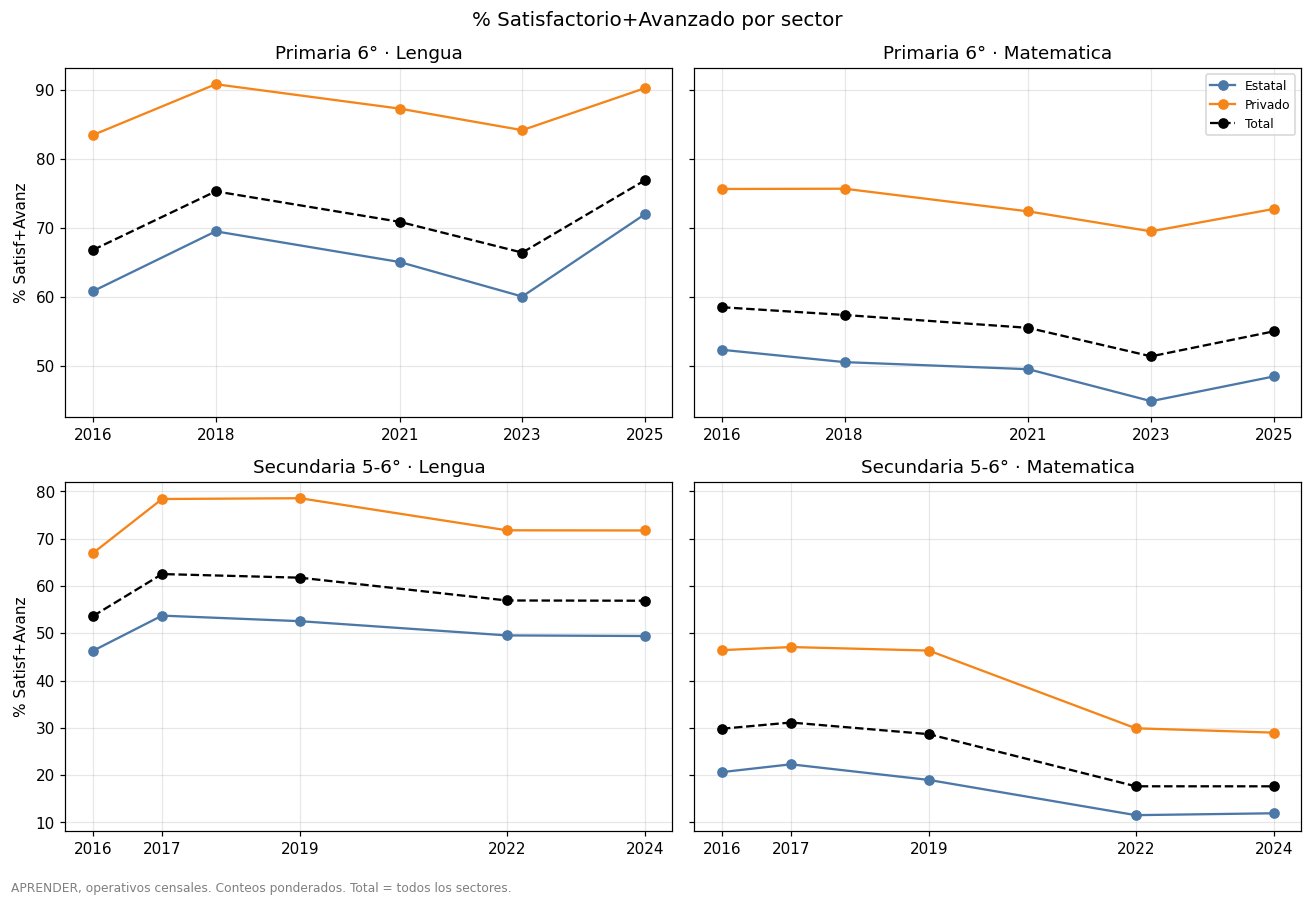

sector                           Estatal  Privado  \
cohorte         area       anio                     
Primaria 6°     Lengua     2016     60.8     83.4   
                           2018     69.5     90.8   
                           2021     65.1     87.3   
                           2023     60.1     84.1   
                           2025     72.0     90.2   
                Matematica 2016     52.4     75.6   
                           2018     50.6     75.7   
                           2021     49.5     72.4   
                           2023     44.9     69.5   
                           2025     48.5     72.7   
Secundaria 5-6° Lengua     2016     46.3     67.0   
                           2017     53.7     78.4   
                           2019     52.6     78.6   
                           2022     49.6     71.8   
                           2024     49.4     71.8   
                Matematica 2016     20.6     46.4   
                           2017     22.3     47.1   
                           2019     19.0     46.3   
                           2022     11.5     29.9   
                           2024     11.9     29.0   

sector                           brecha pp (Privado − Estatal)  
cohorte         area       anio                                 
Primaria 6°     Lengua     2016                           22.6  
                           2018                           21.3  
                           2021                           22.2  
                           2023                           24.1  
                           2025                           18.2  
                Matematica 2016                           23.3  
                           2018                           25.1  
                           2021                           22.8  
                           2023                           24.6  
                           2025                           24.2  
Secundaria 5-6° Lengua     2016                           20.7  
                           2017                           24.7  
                           2019                           26.0  
                           2022                           22.2  
                           2024                           22.3  
                Matematica 2016                           25.8  
                           2017                           24.8  
                           2019                           27.4  
                           2022                           18.4  
                           2024                           17.1

In [4]:
def panel_grupos(col, grupos, colores, titulo, archivo, pie):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
    for i, coh in enumerate(COHORTES):
        for j, area in enumerate(AREAS):
            ax = axes[i, j]; sub = D[(D.cohorte == coh) & (D.area == area)]
            g = indicadores(sub, ['anio', col])['Satisf+Avanz'].unstack(col)
            for grupo, color in zip(grupos, colores):
                ax.plot(g.index, g[grupo], '-o', color=color, label=grupo)
            ax.plot(g.index, nac.loc[(coh, area), 'Satisf+Avanz'], 'k--o', label='Total')
            ax.set_title(f'{coh} · {area}'); ax.set_xticks(g.index); ax.grid(alpha=.3)
            if j == 0: ax.set_ylabel('% Satisf+Avanz')
    axes[0, 1].legend(fontsize=8, loc='best')
    fig.suptitle(titulo, fontsize=13); fig.tight_layout(); nota(fig, pie)
    guardar(fig, archivo); plt.show()

def tabla_brecha(col, alto, bajo):
    t = indicadores(D, ['cohorte', 'area', 'anio', col])['Satisf+Avanz'].unstack(col)
    t[f'brecha pp ({alto} − {bajo})'] = t[alto] - t[bajo]
    return t

panel_grupos('sector', ['Estatal', 'Privado'], ['#4C78A8', '#F58518'],
             '% Satisfactorio+Avanzado por sector', 'B1_sector',
             'APRENDER, operativos censales. Conteos ponderados. Total = todos los sectores.')
brecha_sector = tabla_brecha('sector', 'Privado', 'Estatal')
brecha_sector.round(1)

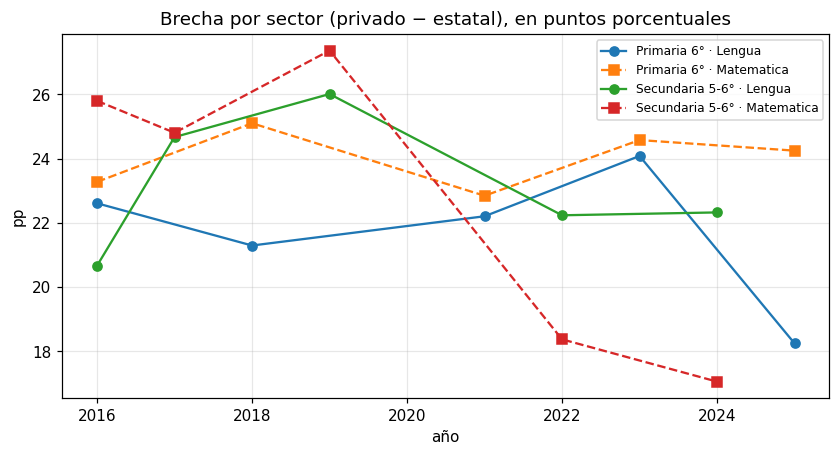

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.3))
for (coh, area), g in brecha_sector.groupby(level=['cohorte', 'area']):
    s = g.droplevel(['cohorte', 'area'])['brecha pp (Privado − Estatal)']
    ax.plot(s.index, s.values, '-o' if area == 'Lengua' else '--s', label=f'{coh} · {area}')
ax.set_title('Brecha por sector (privado − estatal), en puntos porcentuales')
ax.set_xlabel('año'); ax.set_ylabel('pp'); ax.grid(alpha=.3); ax.legend(fontsize=8)
guardar(fig, 'B2_brecha_sector_pp'); plt.show()

---
## C · Brecha por ámbito (urbano vs rural)
Misma lectura que B. La tabla final cruza **sector × ámbito** (estatal rural, estatal urbano, privado rural, privado urbano).

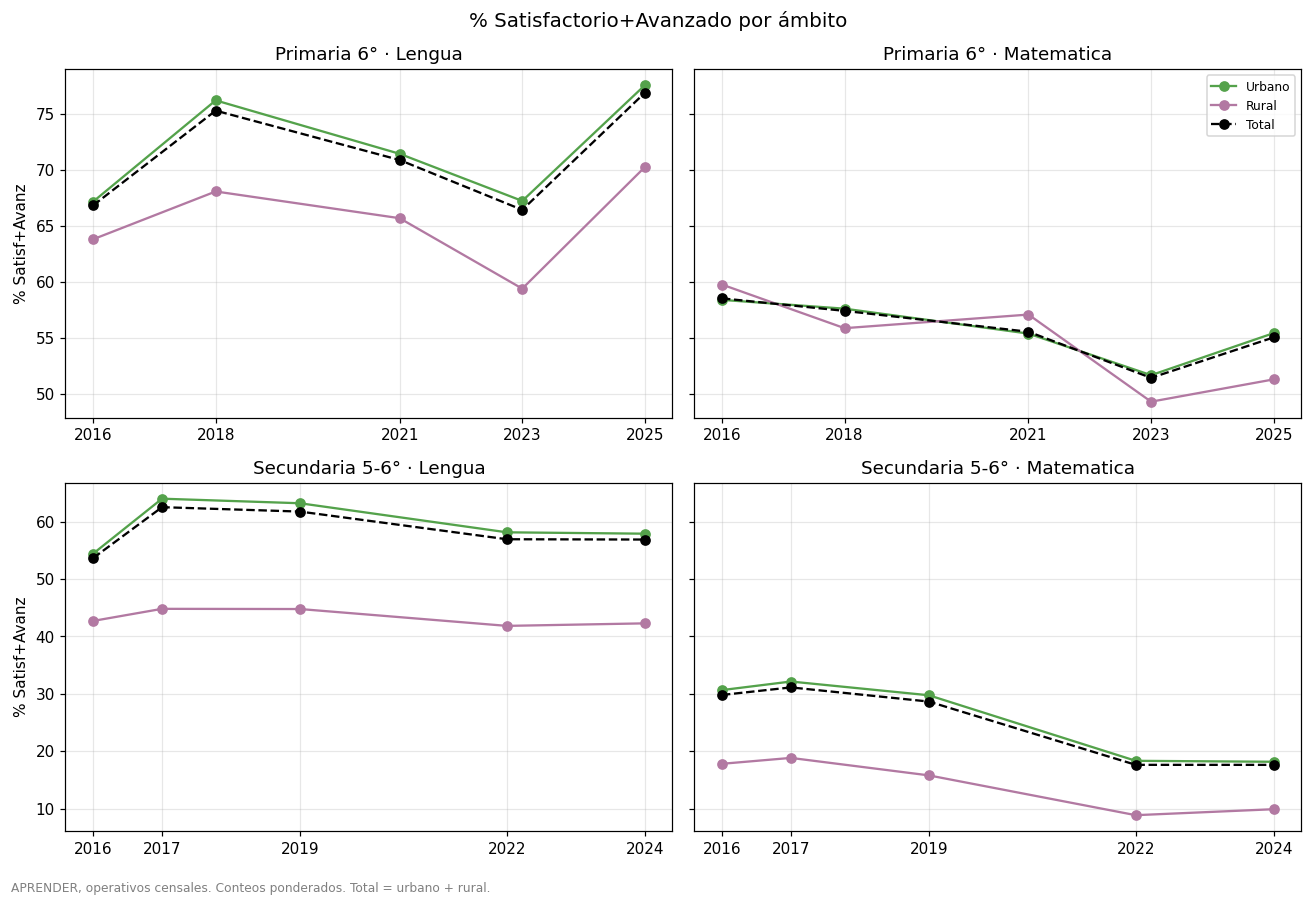

ambito                           Rural  Urbano  brecha pp (Urbano − Rural)
cohorte         area       anio                                           
Primaria 6°     Lengua     2016   63.8    67.2                         3.4
                           2018   68.1    76.2                         8.1
                           2021   65.7    71.4                         5.8
                           2023   59.4    67.2                         7.8
                           2025   70.2    77.6                         7.3
                Matematica 2016   59.7    58.4                        -1.4
                           2018   55.8    57.6                         1.7
                           2021   57.1    55.4                        -1.7
                           2023   49.3    51.6                         2.4
                           2025   51.3    55.4                         4.1
Secundaria 5-6° Lengua     2016   42.7    54.4                        11.7
                           2017   44.8    64.0                        19.2
                           2019   44.8    63.2                        18.4
                           2022   41.8    58.1                        16.3
                           2024   42.3    57.9                        15.6
                Matematica 2016   17.8    30.7                        12.8
                           2017   18.8    32.2                        13.3
                           2019   15.8    29.8                        14.0
                           2022    8.9    18.3                         9.5
                           2024    9.9    18.2                         8.3

In [6]:
panel_grupos('ambito', ['Urbano', 'Rural'], ['#54A24B', '#B279A2'],
             '% Satisfactorio+Avanzado por ámbito', 'C1_ambito',
             'APRENDER, operativos censales. Conteos ponderados. Total = urbano + rural.')
brecha_ambito = tabla_brecha('ambito', 'Urbano', 'Rural')
brecha_ambito.round(1)

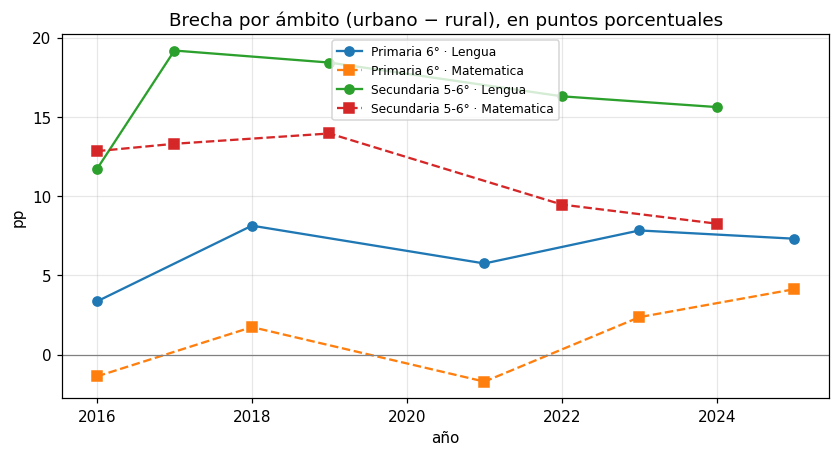

% Satisf+Avanz por sector × ámbito:


grupo                            Estatal rural  Estatal urbano  Privado rural  \
cohorte         area       anio                                                 
Primaria 6°     Lengua     2016           63.6            60.4           76.6   
                           2018           67.7            69.8           82.9   
                           2021           65.4            65.0           78.5   
                           2023           59.0            60.2           75.0   
                           2025           69.9            72.3           82.3   
                Matematica 2016           59.6            51.2           65.0   
                           2018           55.6            49.7           67.8   
                           2021           56.9            48.5           66.2   
                           2023           49.0            44.3           60.9   
                           2025           50.9            48.2           66.0   
Secundaria 5-6° Lengua     2016           40.9            46.8           56.1   
                           2017           42.9            55.0           59.7   
                           2019           42.7            53.8           61.5   
                           2022           40.4            50.6           55.1   
                           2024           40.5            50.3           57.6   
                Matematica 2016           15.9            21.1           32.3   
                           2017           16.9            22.9           34.1   
                           2019           13.7            19.6           32.1   
                           2022            8.0            11.9           16.3   
                           2024            8.9            12.2           19.0   

grupo                            Privado urbano  
cohorte         area       anio                  
Primaria 6°     Lengua     2016            83.5  
                           2018            90.9  
                           2021            87.3  
                           2023            84.2  
                           2025            90.3  
                Matematica 2016            75.7  
                           2018            75.7  
                           2021            72.4  
                           2023            69.6  
                           2025            72.8  
Secundaria 5-6° Lengua     2016            67.2  
                           2017            78.9  
                           2019            79.0  
                           2022            72.2  
                           2024            72.0  
                Matematica 2016            46.8  
                           2017            47.4  
                           2019            46.7  
                           2022            30.2  
                           2024            29.2

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.3))
for (coh, area), g in brecha_ambito.groupby(level=['cohorte', 'area']):
    s = g.droplevel(['cohorte', 'area'])['brecha pp (Urbano − Rural)']
    ax.plot(s.index, s.values, '-o' if area == 'Lengua' else '--s', label=f'{coh} · {area}')
ax.axhline(0, color='gray', lw=.8)
ax.set_title('Brecha por ámbito (urbano − rural), en puntos porcentuales')
ax.set_xlabel('año'); ax.set_ylabel('pp'); ax.grid(alpha=.3); ax.legend(fontsize=8)
guardar(fig, 'C2_brecha_ambito_pp'); plt.show()

sector_ambito = indicadores(D.assign(grupo=D.sector + ' ' + D.ambito.str.lower()),
                           ['cohorte', 'area', 'anio', 'grupo'])
print('% Satisf+Avanz por sector × ámbito:')
sector_ambito['Satisf+Avanz'].unstack('grupo').round(1)

---
## D · Brechas entre provincias
- **D.1–D.2:** mapa de calor provincia × año (% Satisf+Avanz), ordenado por el último año. Gris = sin datos.
- **D.3:** cambio entre el primer y el último año de cada cohorte, por provincia.
- **D.4:** **dispersión territorial** en el tiempo: distancia entre la mejor y la peor provincia y desvío estándar
  entre provincias (sin ponderar por tamaño).

> **Cómo leer la dispersión:** que se achique no siempre es buena noticia. Si todas las provincias caen hacia valores
> bajos (como Matemática en Secundaria desde 2022), la distancia entre ellas se reduce por "piso", no por mejora de
> las más rezagadas. Leerla siempre junto con el nivel (D.1–D.3).

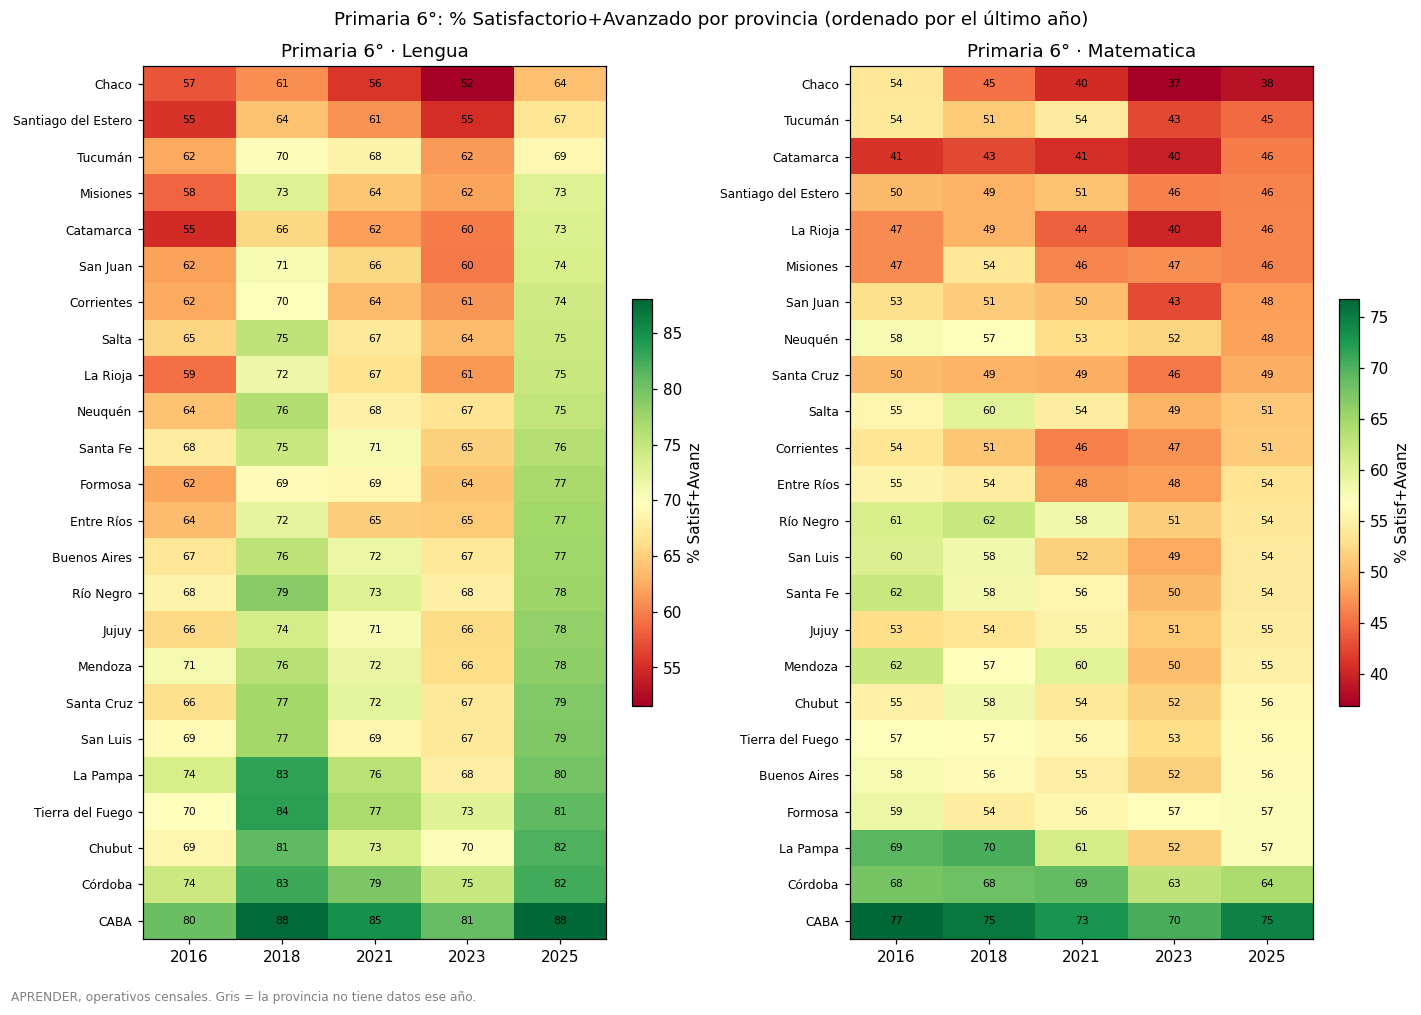

In [8]:
prov = indicadores(D, ['cohorte', 'area', 'anio', 'provincia'])

def heatmap_cohorte(coh, archivo):
    fig, axes = plt.subplots(1, 2, figsize=(13, 9))
    for ax, area in zip(axes, AREAS):
        m = prov.loc[(coh, area), 'Satisf+Avanz'].unstack('anio')
        m = m.sort_values(m.columns[-1], ascending=True)
        cmap = plt.get_cmap('RdYlGn').copy(); cmap.set_bad('lightgray')
        im = ax.imshow(np.ma.masked_invalid(m.values), aspect='auto', cmap=cmap)
        ax.set_yticks(range(len(m))); ax.set_yticklabels(m.index, fontsize=8)
        ax.set_xticks(range(m.shape[1])); ax.set_xticklabels(m.columns)
        for (r, k), v in np.ndenumerate(m.values):
            if not np.isnan(v): ax.text(k, r, f'{v:.0f}', ha='center', va='center', fontsize=7)
        ax.set_title(f'{coh} · {area}'); fig.colorbar(im, ax=ax, fraction=.04, label='% Satisf+Avanz')
    fig.suptitle(f'{coh}: % Satisfactorio+Avanzado por provincia (ordenado por el último año)', fontsize=12)
    fig.tight_layout(); nota(fig, 'APRENDER, operativos censales. Gris = la provincia no tiene datos ese año.')
    guardar(fig, archivo); plt.show()

heatmap_cohorte('Primaria 6°', 'D1_provincias_primaria6')

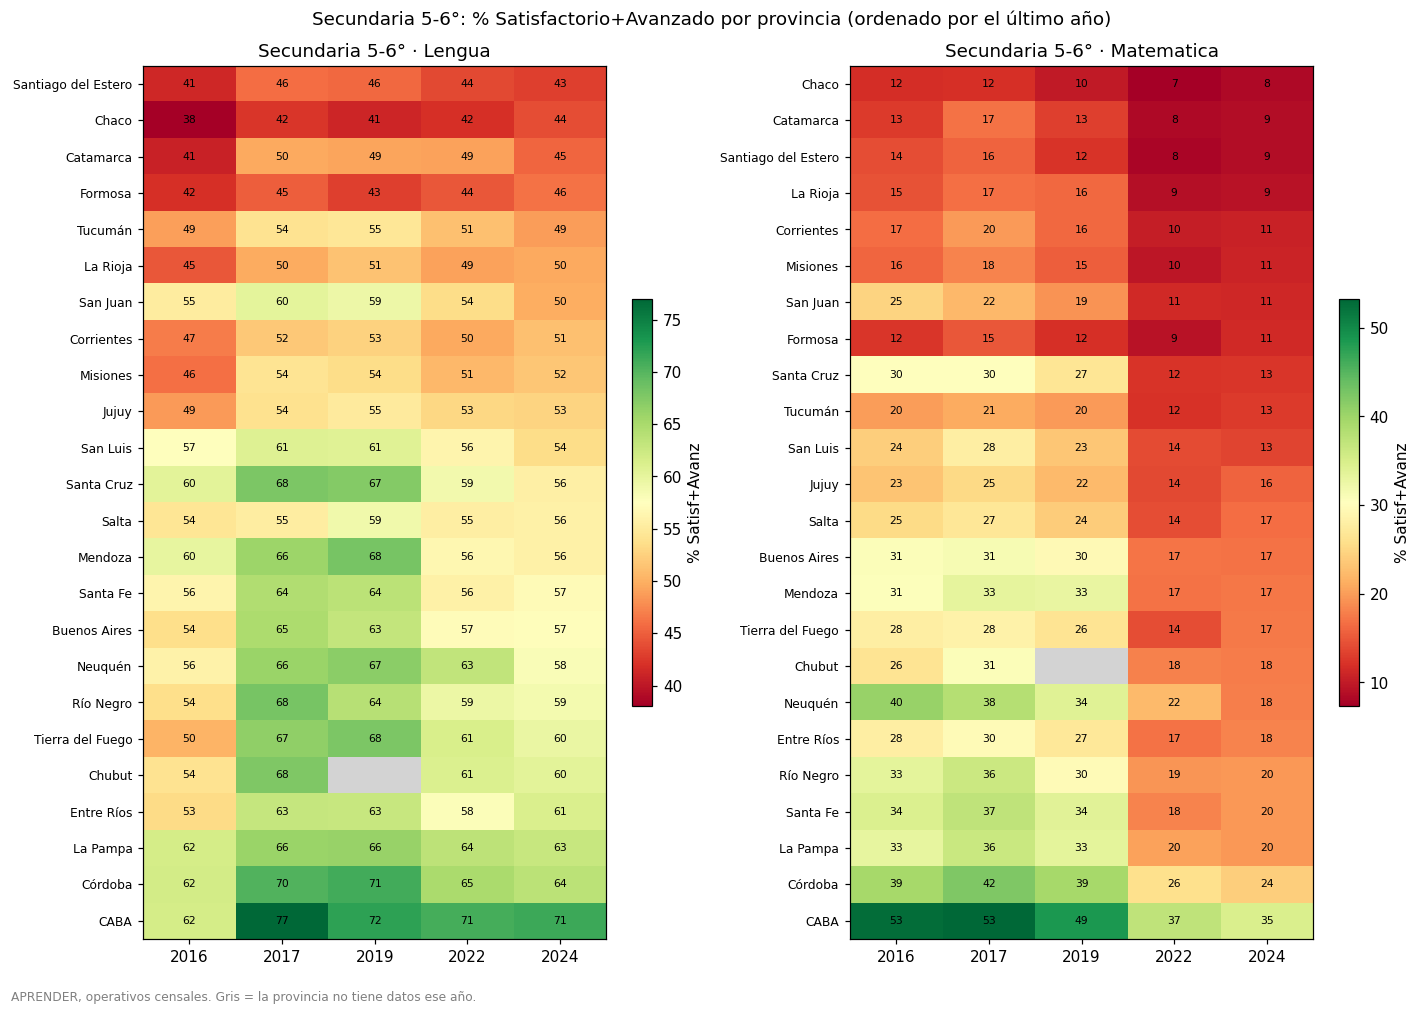

In [9]:
heatmap_cohorte('Secundaria 5-6°', 'D2_provincias_secundaria56')

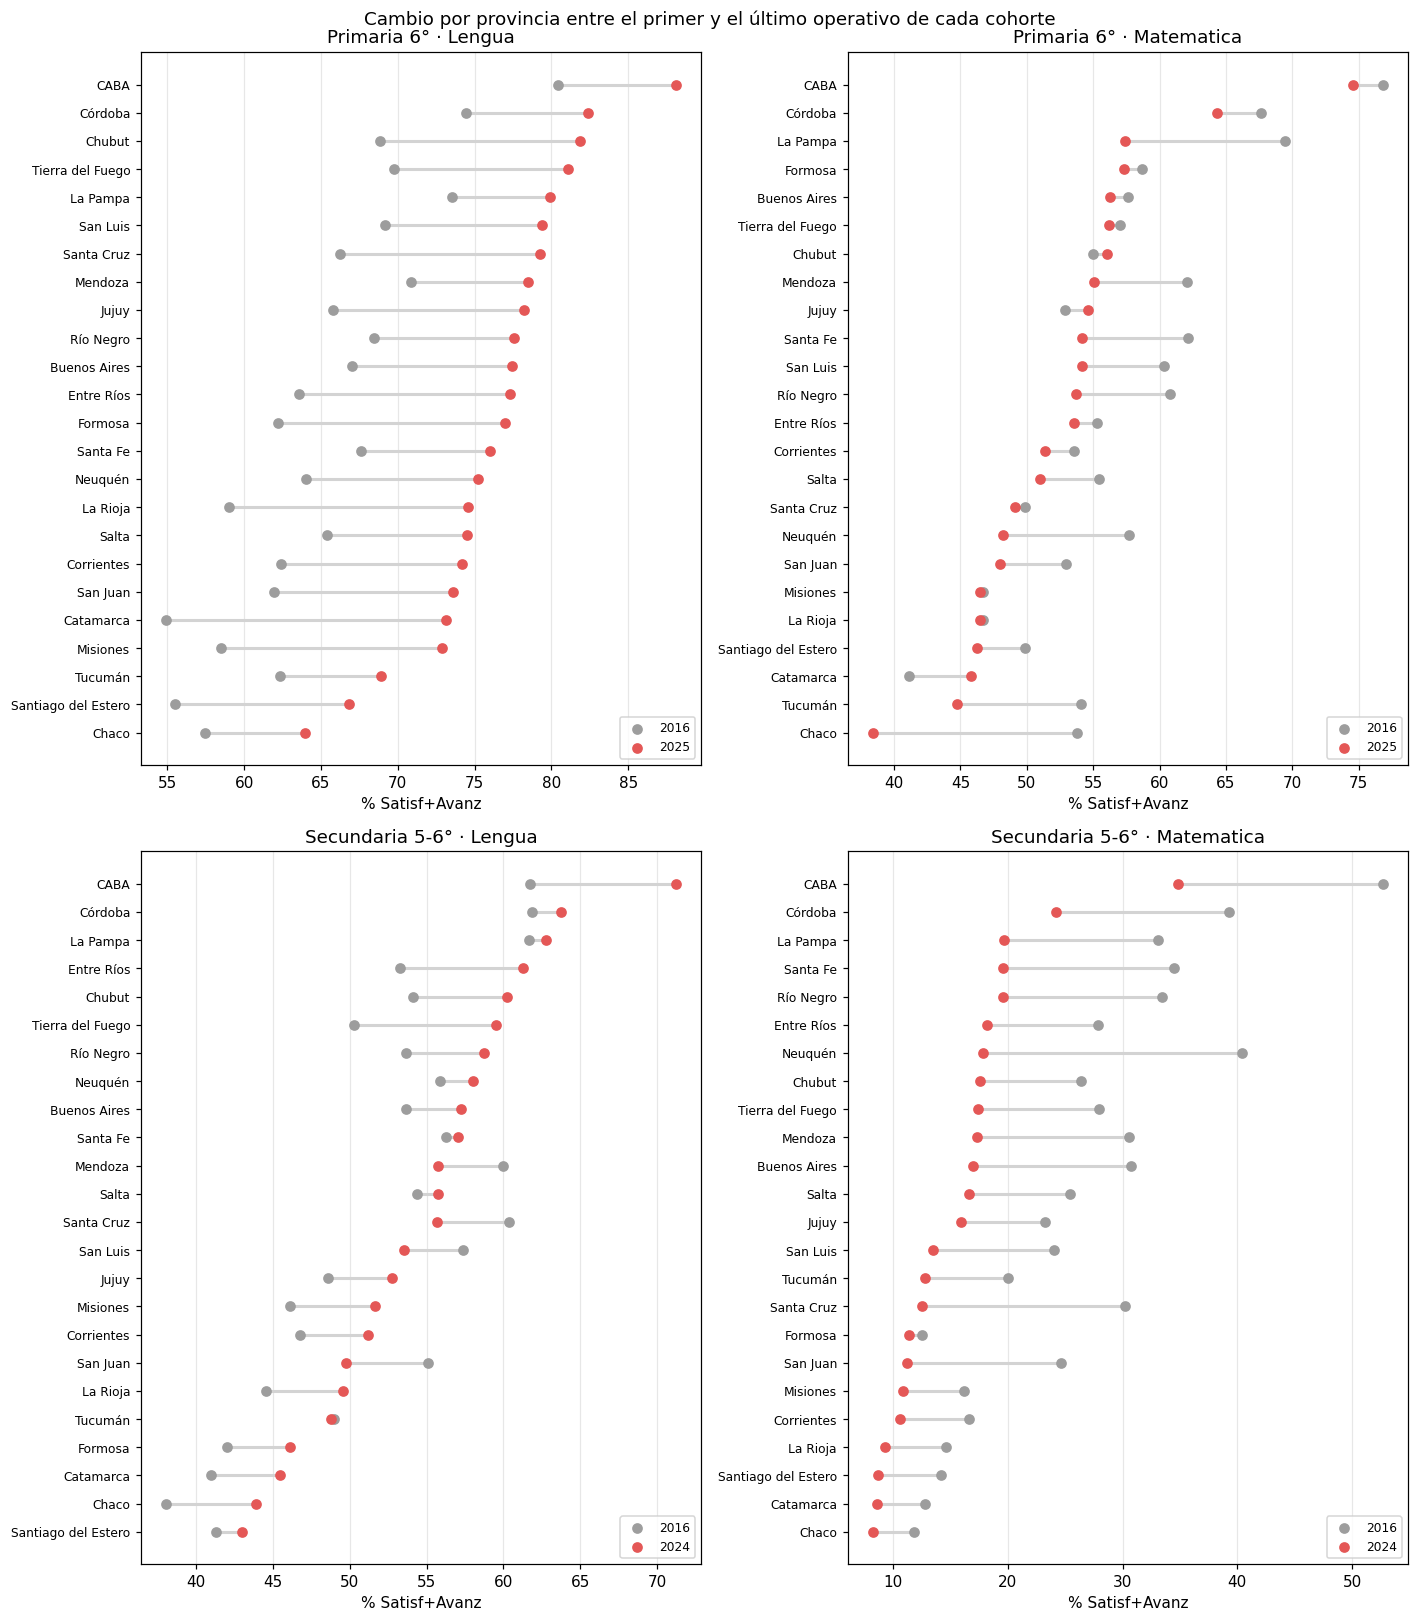

Cambio en pp por provincia (último − primer año de cada cohorte); ordenado por Primaria 6° · Matemática:


cohorte             Primaria 6°            Secundaria 5-6°           
area                     Lengua Matematica          Lengua Matematica
provincia                                                            
Chaco                       6.5      -15.3             5.8       -3.5
La Pampa                    6.3      -12.0             1.1      -13.5
Neuquén                    11.2       -9.5             2.1      -22.6
Tucumán                     6.6       -9.4            -0.2       -7.2
Santa Fe                    8.4       -8.0             0.8      -14.9
Río Negro                   9.1       -7.1             5.1      -13.9
Mendoza                     7.6       -7.0            -4.2      -13.2
San Luis                   10.2       -6.2            -3.9      -10.5
San Juan                   11.6       -5.0            -5.3      -13.4
Salta                       9.1       -4.5             1.4       -8.9
Santiago del Estero        11.3       -3.6             1.7       -5.5
Córdoba                     8.0       -3.3             1.9      -15.2
CABA                        7.7       -2.2             9.5      -17.9
Corrientes                 11.8       -2.2             4.4       -6.0
Entre Ríos                 13.8       -1.8             8.0       -9.6
Buenos Aires               10.4       -1.4             3.6      -13.8
Formosa                    14.8       -1.4             4.1       -1.1
Tierra del Fuego           11.3       -0.8             9.3      -10.5
Santa Cruz                 13.0       -0.8            -4.7      -17.7
La Rioja                   15.5       -0.3             5.0       -5.3
Misiones                   14.4       -0.2             5.5       -5.3
Chubut                     13.0        1.0             6.2       -8.8
Jujuy                      12.4        1.7             4.2       -7.3
Catamarca                  18.2        4.6             4.5       -4.1

In [10]:
filas = []
for coh, c in COHORTES.items():
    ini, fin = c['anios'][0], c['anios'][-1]
    for area in AREAS:
        m = prov.loc[(coh, area), 'Satisf+Avanz'].unstack('anio')
        filas.append(pd.DataFrame({'cohorte': coh, 'area': area, 'provincia': m.index,
                                   'primer_anio': ini, 'ultimo_anio': fin,
                                   'valor_inicial': m[ini].values, 'valor_final': m[fin].values}))
cambio_prov = pd.concat(filas, ignore_index=True)
cambio_prov['cambio_pp'] = cambio_prov.valor_final - cambio_prov.valor_inicial

fig, axes = plt.subplots(2, 2, figsize=(13, 15))
for i, coh in enumerate(COHORTES):
    for j, area in enumerate(AREAS):
        ax = axes[i, j]
        t = cambio_prov[(cambio_prov.cohorte == coh) & (cambio_prov.area == area)].sort_values('valor_final')
        y = np.arange(len(t))
        ax.hlines(y, t.valor_inicial, t.valor_final, color='lightgray', lw=2)
        ax.scatter(t.valor_inicial, y, color='#9D9D9D', label=str(t.primer_anio.iloc[0]), zorder=3)
        ax.scatter(t.valor_final, y, color='#E45756', label=str(t.ultimo_anio.iloc[0]), zorder=3)
        ax.set_yticks(y); ax.set_yticklabels(t.provincia, fontsize=8); ax.grid(axis='x', alpha=.3)
        ax.set_title(f'{coh} · {area}'); ax.set_xlabel('% Satisf+Avanz'); ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Cambio por provincia entre el primer y el último operativo de cada cohorte', fontsize=12)
fig.tight_layout(); guardar(fig, 'D3_cambio_provincias'); plt.show()
print('Cambio en pp por provincia (último − primer año de cada cohorte); ordenado por Primaria 6° · Matemática:')
cambio_prov.pivot_table(index='provincia', columns=['cohorte', 'area'], values='cambio_pp').sort_values(
    ('Primaria 6°', 'Matematica')).round(1)

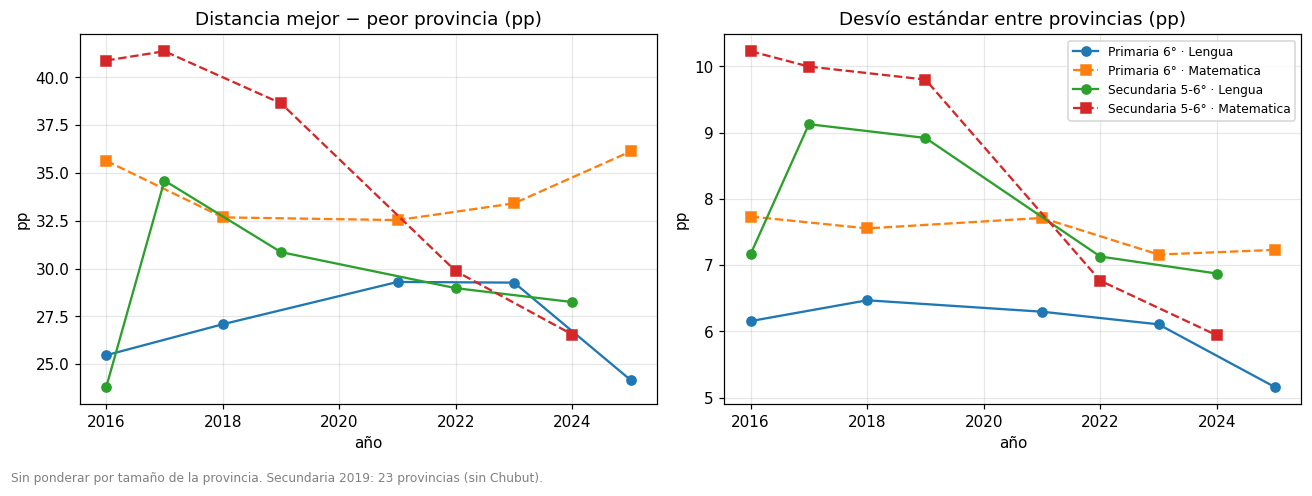

provincias  maximo  minimo  rango_pp  \
cohorte         area       anio                                         
Primaria 6°     Lengua     2016          24    80.4    54.9      25.5   
                           2018          24    87.9    60.8      27.1   
                           2021          24    84.9    55.6      29.3   
                           2023          24    80.8    51.5      29.3   
                           2025          24    88.1    63.9      24.2   
                Matematica 2016          24    76.8    41.2      35.6   
                           2018          24    75.2    42.6      32.7   
                           2021          24    73.0    40.5      32.5   
                           2023          24    70.3    36.9      33.4   
                           2025          24    74.5    38.4      36.1   
Secundaria 5-6° Lengua     2016          24    61.8    38.1      23.8   
                           2017          24    77.0    42.4      34.6   
                           2019          23    72.1    41.2      30.9   
                           2022          24    70.8    41.9      29.0   
                           2024          24    71.2    43.0      28.2   
                Matematica 2016          24    52.7    11.8      40.9   
                           2017          24    53.3    11.9      41.4   
                           2019          23    48.6     9.9      38.6   
                           2022          24    37.2     7.3      29.9   
                           2024          24    34.8     8.2      26.5   

                                 desvio_pp    mejor                 peor  
cohorte         area       anio                                           
Primaria 6°     Lengua     2016        6.2     CABA            Catamarca  
                           2018        6.5     CABA                Chaco  
                           2021        6.3     CABA                Chaco  
                           2023        6.1     CABA                Chaco  
                           2025        5.2     CABA                Chaco  
                Matematica 2016        7.7     CABA            Catamarca  
                           2018        7.6     CABA            Catamarca  
                           2021        7.7     CABA                Chaco  
                           2023        7.2     CABA                Chaco  
                           2025        7.2     CABA                Chaco  
Secundaria 5-6° Lengua     2016        7.2  Córdoba                Chaco  
                           2017        9.1     CABA                Chaco  
                           2019        8.9     CABA                Chaco  
                           2022        7.1     CABA                Chaco  
                           2024        6.9     CABA  Santiago del Estero  
                Matematica 2016       10.2     CABA                Chaco  
                           2017       10.0     CABA                Chaco  
                           2019        9.8     CABA                Chaco  
                           2022        6.8     CABA                Chaco  
                           2024        5.9     CABA                Chaco

In [11]:
def dispersion(g):
    s = g['Satisf+Avanz'].dropna()
    return pd.Series({'provincias': s.size, 'maximo': s.max(), 'minimo': s.min(), 'rango_pp': s.max() - s.min(),
                      'desvio_pp': s.std(), 'mejor': s.idxmax()[-1], 'peor': s.idxmin()[-1]})
disp = prov.groupby(level=['cohorte', 'area', 'anio']).apply(dispersion)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, medida, titulo in [(axes[0], 'rango_pp', 'Distancia mejor − peor provincia (pp)'),
                           (axes[1], 'desvio_pp', 'Desvío estándar entre provincias (pp)')]:
    for (coh, area), g in disp.groupby(level=['cohorte', 'area']):
        s = g.droplevel(['cohorte', 'area'])[medida].astype(float)
        ax.plot(s.index, s.values, '-o' if area == 'Lengua' else '--s', label=f'{coh} · {area}')
    ax.set_title(titulo); ax.set_xlabel('año'); ax.grid(alpha=.3)
axes[0].set_ylabel('pp'); axes[1].set_ylabel('pp'); axes[1].legend(fontsize=8)
fig.tight_layout(); nota(fig, 'Sin ponderar por tamaño de la provincia. Secundaria 2019: 23 provincias (sin Chubut).')
guardar(fig, 'D4_dispersion_provincial'); plt.show()
disp.assign(**{c: disp[c].astype(float).round(1) for c in ['maximo', 'minimo', 'rango_pp', 'desvio_pp']})

---
## E · ¿Y la brecha por nivel socioeconómico?
**No se puede calcular con las bases agregadas.** Cada archivo trae, por celda geográfica, cuántos estudiantes hay en
cada nivel de desempeño y —por separado— cuántos en cada nivel socioeconómico, pero **no cuántos de un NSE están en
cada nivel de desempeño**. Sin esa distribución conjunta, cualquier "brecha por NSE" sería una inferencia ecológica.

Alternativas: (1) los **microdatos 2024** (`Base_publica_Ap2024.sav`, secundaria, y `Base_publica_prim_Ap2024.sav`,
primaria 3°), que sí tienen desempeño y NSE por estudiante (solo una foto 2024, requiere `pyreadstat`); (2) la
plataforma de microdatos por escuela de la Secretaría de Educación, que garantiza trazabilidad entre años.

---
## F · Descargar gráficos y tablas
Guarda todas las tablas en `brechas_aprender.xlsx` dentro de `graficos_brechas/`, comprime la carpeta en un `.zip`
y, en **Colab**, **lo descarga**.

In [12]:
hojas = {
    'total_pais': tabla_nac,
    'sector': brecha_sector,
    'ambito': brecha_ambito,
    'sector_ambito': sector_ambito,
    'provincias': prov,
    'provincias_cambio': cambio_prov.set_index(['cohorte', 'area', 'provincia']),
    'dispersion_provincial': disp,
    'cobertura': cobertura,
}
ruta_xlsx = os.path.join(GRAF, 'brechas_aprender.xlsx')
with pd.ExcelWriter(ruta_xlsx, engine='openpyxl') as xw:
    for nombre, t in hojas.items():
        t = t.copy()
        if isinstance(t.columns, pd.MultiIndex):
            t.columns = [' · '.join(map(str, c)) for c in t.columns]
        num = t.select_dtypes('number').columns
        t[num] = t[num].round(2)
        t.to_excel(xw, sheet_name=nombre)
print('Archivos a descargar:')
for n in sorted(os.listdir(GRAF)): print('  -', n)
zip_path = shutil.make_archive(os.path.join(os.path.dirname(GRAF), 'graficos_brechas'), 'zip', GRAF)
print('\nZIP:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
if in_colab():
    from google.colab import files
    files.download(zip_path)
    print('Descargando el zip...')
else:
    print('Entorno local: los archivos quedan en', GRAF)

Archivos a descargar:
  - B1_sector.png
  - B2_brecha_sector_pp.png
  - C1_ambito.png
  - C2_brecha_ambito_pp.png
  - D1_provincias_primaria6.png
  - D2_provincias_secundaria56.png
  - D3_cambio_provincias.png
  - D4_dispersion_provincial.png
  - brechas_aprender.xlsx

ZIP: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_brechas.zip (2.7 MB)
Entorno local: los archivos quedan en C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_brechas
